In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [4]:
file_path = r"C:\Users\harry\OneDrive - Loughborough University\25PHC902 Group Project\DriveSim\Data Sets\KIT\10.35097-1130\10.35097-1130\data\dataset\OBD-II-Dataset\OBD-II-Dataset\2017-07-05_Seat_Leon_RT_S_Stau.csv"

In [6]:
def timeToFloat(time_column_title):
    # Ensure strings
    s = time_column_title.astype(str).str.strip()
    s = "00:" + s # Convert mm:ss.f → hh:mm:ss.f

    td = pd.to_timedelta(s, errors="coerce")
    if pd.isna(td).any():
        bad = time_column_title[pd.isna(td)].head(10).tolist()
        raise ValueError(f"Unparseable time values (showing up to 10): {bad}")

    seconds = td.dt.total_seconds().to_numpy()

    # ---- UNWRAP ROLLOVER (59:59.9 → 00:00.0) ----
    unwrapped = seconds.copy()
    rollover_offset = 0.0

    for i in range(1, len(seconds)):
        if seconds[i] < seconds[i - 1]:
            # minute counter rolled over
            rollover_offset += 60.0 * 60.0  # add 1 hour
        unwrapped[i] += rollover_offset

    # Normalize to start at 0
    return unwrapped - unwrapped[0]


In [8]:
def PlotXagainstY(x,y,x_column_title, y_column_title):
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, marker='o', linestyle='-', color='blue')
    plt.xlabel(x_column_title)
    plt.ylabel(y_column_title)
    plt.title(f"Line Graph of {y_column_title} against {x_column_title}")
    plt.grid(True)
    plt.show()

In [15]:
def convertDataToFormat(file_path, x_column_title): 
    usecols = [x_column_title]
    df = pd.read_csv(file_path, usecols=usecols)
    
    if x_column_title == "Time":
        df[x_column_title] = timeToFloat(df[x_column_title])
    else:
        df[x_column_title] = df[x_column_title]
    df = df.drop(range(0,9))
    
    x = df[x_column_title].to_numpy()
   
    return x

In [155]:
def movingAverage(x, window=9):

    x = np.asarray(x, dtype=float)
    window = int(window)

    if window < 2:
        return x

    if window % 2 == 0:
        window += 1

    w = np.ones(window) / window
    return np.convolve(x, w, mode="same")

**Braking Force**

In [221]:
vehicleMass_kg = 1241
wheelRadius_m = 0.30
frontBias = 0.65

In [189]:
def computeAcceleration(file_path, time_title, speed_title, smooth_window=9):
    time_seconds = convertDataToFormat(file_path, time_title)
    speed_kph = convertDataToFormat(file_path, speed_title)

    speed_mps = speed_kph/3.6
    speed_mps = movingAverage(speed_mps, window=smooth_window)

    acceleration = np.gradient(speed_mps,time_seconds)
    return time_seconds, speed_kph, speed_mps, acceleration

In [191]:
time_seconds, speed_kph, speed_mps, acceleration = computeAcceleration(file_path, "Time", "Vehicle Speed Sensor [km/h]")


C:\Users\harry\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
C:\Users\harry\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
C:\Users\harry\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
C:\Users\harry\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1250: RuntimeWarning: invalid value encountered in multiply
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
C:\Users\harry\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
C:\Users\harry\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1259: Runti

The simple braking force calculation uses a very basic approach to braking. 

$F_{brake} \approx -ma$

Include a mask to remove any noise around $0 ms^{-2}$

In [194]:
def computeBrakeForceSimple(vehicleMass_kg, acceleration_mps2):

    F_brake = -vehicleMass_kg * acceleration_mps2
    F_brake = np.maximum(F_brake, 0.0)

    return F_brake

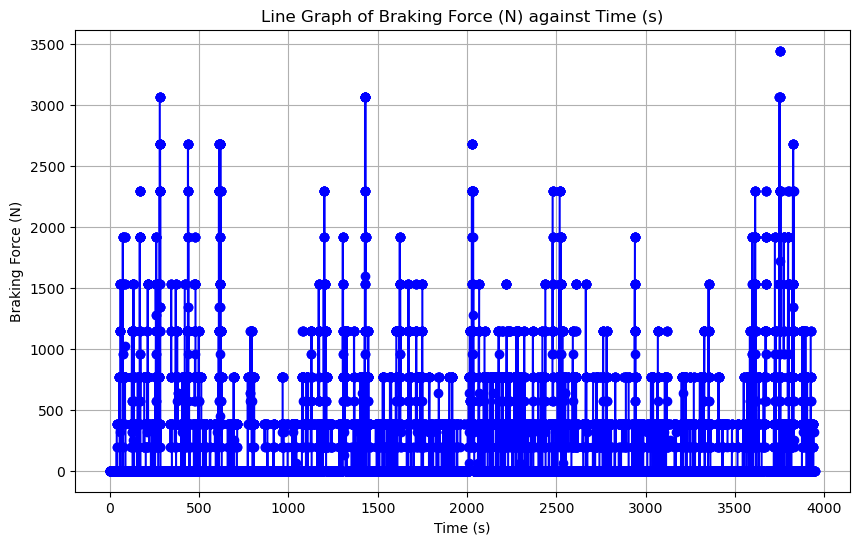

In [196]:
F_brake_N = computeBrakeForceSimple(vehicleMass_kg, acceleration)
PlotXagainstY(time_seconds, F_brake_N, "Time (s)", "Braking Force (N)")

In [197]:
def detectBraking(acceleration_mps2, threshold_mps2=-0.3):

    brakingMask = (acceleration_mps2 < threshold_mps2)
    return brakingMask

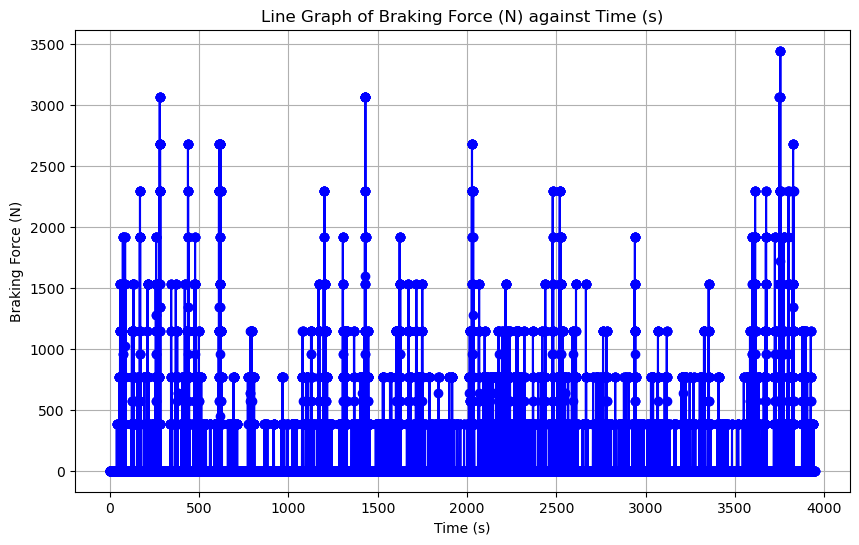

In [200]:
brakingMask = detectBraking(acceleration, threshold_mps2=-0.3)
F_brake_N_masked = np.where(brakingMask, F_brake_N, 0.0)

PlotXagainstY(time_seconds, F_brake_N_masked, "Time (s)", "Braking Force (N)")

Now we go to more accurate **braking force**.

This includes other forces acting on the car which will affect the breaking force.

$F_{Brake} = -(ma) - F_{drag} - F_{roll}$

where $F_{drag} = \frac{1}{2}\rho Cd A v^2$

and $F_{roll} =  Crr M g$

In [202]:
def computeBrakeForce(vehicleMass_kg, acceleration_mps2, speed_mps,
                      rho_air=1.225, Cd=0.30, frontalArea_m2=2.2,
                      Crr=0.012, g=9.81):

    F_drag = 0.5 * rho_air * Cd * frontalArea_m2 * (speed_mps ** 2)
    F_roll = Crr * vehicleMass_kg * g

    F_brake = -(vehicleMass_kg * acceleration_mps2) - F_drag - F_roll
    F_brake = np.maximum(F_brake, 0.0)

    return F_brake, F_drag, F_roll

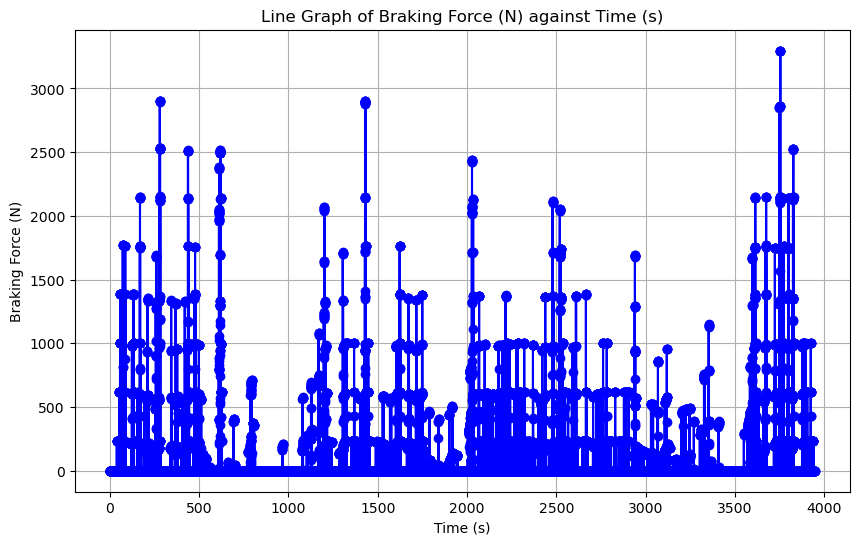

In [205]:
F_brake_N, F_drag_N, F_roll_N = computeBrakeForce(vehicleMass_kg, acceleration, speed_mps)

brakingMask = detectBraking(acceleration, threshold_mps2=-0.3)
F_brake_N_masked = np.where(brakingMask, F_brake_N, 0.0)

PlotXagainstY(time_seconds, F_brake_N_masked, "Time (s)", "Braking Force (N)")

In [207]:
print("Min acceleration (m/s^2):", np.min(acceleration))
print("Max braking force (N):", np.max(F_brake_N_masked))

Min acceleration (m/s^2): nan
Max braking force (N): 3295.860232317955


Now we will calculate the **braking torque**, for this scenario I will use the wheel braking torque.

$T_{wheel} = F_{brake} \cdot R_{wheel}$

Where: $F_{brake}$ is the longitudinal braking force at the ground 

and $R_{wheel}$ is the effective rolling radius (m)

In [210]:
def computeBrakeTorque(F_brake_N, wheelRadius_m):

    T_brake_Nm = F_brake_N * wheelRadius_m
    return T_brake_Nm

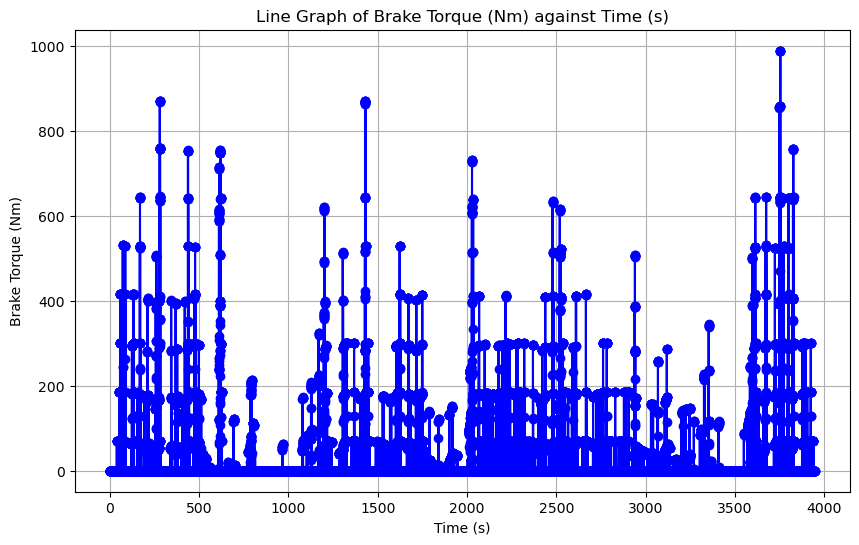

In [216]:
T_brake_Nm = computeBrakeTorque(F_brake_N_masked, wheelRadius_m)

PlotXagainstY(time_seconds, T_brake_Nm, "Time (s)", "Brake Torque (Nm)")

**Front vs Rear tire bias**, useful for usage

$T_{front} = bias_{front} \cdot T_{total}$

$T_{back} = (1 - bias_{front}) \cdot T_{total}$

In [223]:
def splitBrakeTorque(T_brake_Nm, frontBias=0.65):

    T_front = frontBias * T_brake_Nm
    T_rear = (1.0 - frontBias) * T_brake_Nm
    return T_front, T_rear

Now to find the **Braking Power**

$P(t) = F_{brake}(t)v(t)$

In [230]:
def computeBrakePower(F_brake_N, speed_mps):

    P_brake_W = F_brake_N * speed_mps
    return P_brake_W

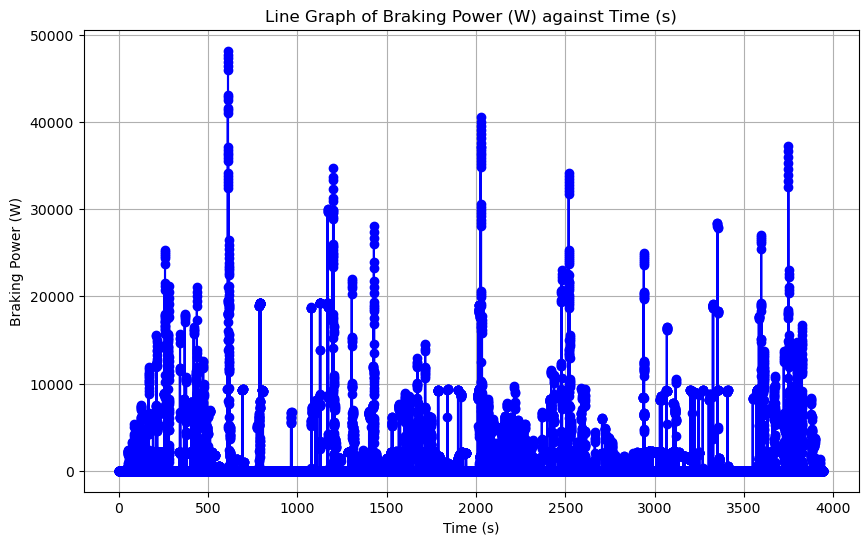

In [236]:
P_brake_W = computeBrakePower(F_brake_N_masked, speed_mps)
PlotXagainstY(time_seconds, P_brake_W, "Time (s)", "Braking Power (W)")

Now we will find the **Braking Energy** which is just integratng power over time

$E(t) = \int P(t) dt$

In [239]:
def computeBrakeEnergy(P_brake_W, time_s):

    dt = np.gradient(time_s)
    E_brake_J = np.cumsum(P_brake_W * dt)

    return E_brake_J

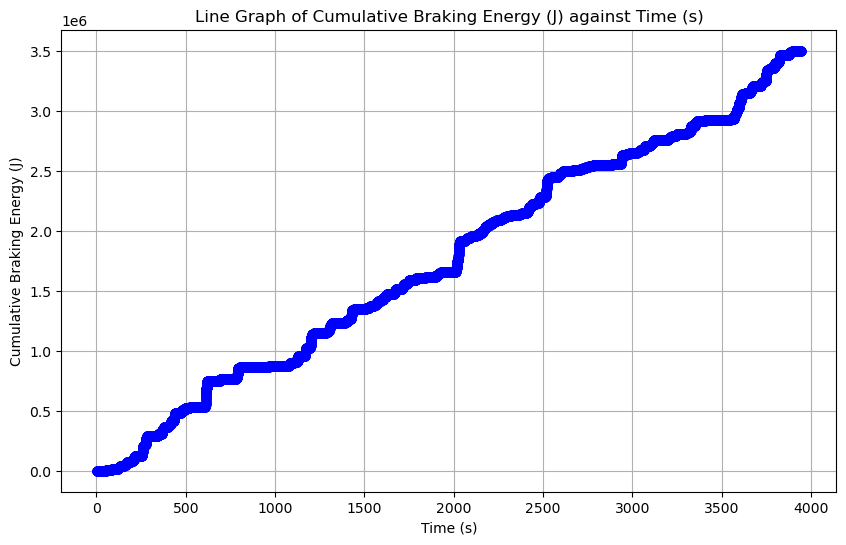

In [241]:
E_brake_J = computeBrakeEnergy(P_brake_W, time_seconds)
PlotXagainstY(time_seconds, E_brake_J, "Time (s)", "Cumulative Braking Energy (J)")

Now I will focus on defining **individual braking events**, this is important for commenting on type of drive and events of the drive

In [244]:
def findBrakingEvents(brakingMask):

    brakingMask = np.asarray(brakingMask, dtype=bool)

    starts = np.where((~brakingMask[:-1]) & (brakingMask[1:]))[0] + 1
    ends = np.where((brakingMask[:-1]) & (~brakingMask[1:]))[0] + 1

    if brakingMask[0]:
        starts = np.r_[0, starts]
    if brakingMask[-1]:
        ends = np.r_[ends, len(brakingMask) - 1]

    return list(zip(starts, ends))

In [252]:
def summariseBrakingEvents(events, time_seconds, speed_mps, F_brake_N, T_brake_Nm, E_brake_J):

    summaries = []

    for (i0, i1) in events:
        t0 = time_seconds[i0]
        t1 = time_seconds[i1]

        v0 = speed_mps[i0]
        v1 = speed_mps[i1]

        peakF = np.max(F_brake_N[i0:i1+1])
        peakT = np.max(T_brake_Nm[i0:i1+1])

        E_event = E_brake_J[i1] - E_brake_J[i0]

        summaries.append({
            "start_time_s": float(t0),
            "end_time_s": float(t1),
            "duration_s": float(t1 - t0),
            "start_speed_mps": float(v0),
            "end_speed_mps": float(v1),
            "peak_brake_force_N": float(peakF),
            "peak_brake_torque_Nm": float(peakT),
            "brake_energy_J": float(E_event)
        })

    return summaries

In [283]:
def mergeCloseEvents(events, max_gap_samples=10):

    if len(events) == 0:
        return events

    merged = [events[0]]

    for (s, e) in events[1:]:
        last_s, last_e = merged[-1]

        if s - last_e <= max_gap_samples:
            merged[-1] = (last_s, e)
        else:
            merged.append((s, e))

    return merged

In [297]:
events = findBrakingEvents(brakingMask)
events = mergeCloseEvents(events, max_gap_samples=10)


P_brake_W = computeBrakePower(F_brake_N_masked, speed_mps)
E_brake_J = computeBrakeEnergy(P_brake_W, time_seconds)

event_summaries = summariseBrakingEvents(
    events, time_seconds, speed_mps, F_brake_N_masked, T_brake_Nm, E_brake_J
)

print("Number of braking events:", len(event_summaries))
print(event_summaries[:3])

Number of braking events: 389
[{'start_time_s': 38.19999999999993, 'end_time_s': 38.80000000000007, 'duration_s': 0.6000000000001364, 'start_speed_mps': 0.7407407407407407, 'end_speed_mps': 0.5555555555555556, 'peak_brake_force_N': 236.79515458267363, 'peak_brake_torque_Nm': 71.03854637480208, 'brake_energy_J': 76.7284379208894}, {'start_time_s': 53.19999999999993, 'end_time_s': 55.000000000000114, 'duration_s': 1.800000000000182, 'start_speed_mps': 3.8888888888888893, 'end_speed_mps': 2.7777777777777777, 'peak_brake_force_N': 616.6994777135925, 'peak_brake_torque_Nm': 185.00984331407776, 'brake_energy_J': 2846.3550314842446}, {'start_time_s': 56.19999999999993, 'end_time_s': 59.30000000000007, 'duration_s': 3.1000000000001364, 'start_speed_mps': 2.654320987654321, 'end_speed_mps': 0.0, 'peak_brake_force_N': 1385.8218628300126, 'peak_brake_torque_Nm': 415.74655884900375, 'brake_energy_J': 2929.608672263085}]


In [287]:
def getBrakingEventDrops(events, time_s, speed_mps):

    eventInfo = []

    for (i0, i1) in events:
        v0 = speed_mps[i0]
        v1 = speed_mps[i1]
        dv = v0 - v1

        eventInfo.append({
            "start_idx": int(i0),
            "end_idx": int(i1),
            "start_time_s": float(time_s[i0]),
            "end_time_s": float(time_s[i1]),
            "start_speed_mps": float(v0),
            "end_speed_mps": float(v1),
            "speed_drop_mps": float(dv)
        })

    return eventInfo

In [289]:
def findLargestBrakingEvents(eventInfo, min_drop_mps=5.0, top_n=5):

    big = [e for e in eventInfo if e["speed_drop_mps"] >= min_drop_mps]
    big = sorted(big, key=lambda e: e["speed_drop_mps"], reverse=True)

    return big[:top_n]

In [291]:
eventInfo = getBrakingEventDrops(events, time_seconds, speed_mps)

topEvents = findLargestBrakingEvents(eventInfo, min_drop_mps=5.0, top_n=5)

print("Top braking events by speed drop:")
for e in topEvents:
    print(e)

Top braking events by speed drop:
{'start_idx': 23640, 'end_idx': 23978, 'start_time_s': 2008.9, 'end_time_s': 2039.7999999999997, 'start_speed_mps': 29.1358024691358, 'end_speed_mps': 4.444444444444445, 'speed_drop_mps': 24.691358024691354}
{'start_idx': 7169, 'end_idx': 7348, 'start_time_s': 608.8000000000001, 'end_time_s': 624.6999999999999, 'start_speed_mps': 23.611111111111104, 'end_speed_mps': 2.2222222222222223, 'speed_drop_mps': 21.388888888888882}
{'start_idx': 14000, 'end_idx': 14208, 'start_time_s': 1193.1999999999998, 'end_time_s': 1209.7999999999997, 'start_speed_mps': 23.302469135802465, 'end_speed_mps': 6.666666666666665, 'speed_drop_mps': 16.6358024691358}
{'start_idx': 42961, 'end_idx': 43208, 'start_time_s': 3656.7999999999997, 'end_time_s': 3675.7000000000003, 'start_speed_mps': 15.771604938271606, 'end_speed_mps': 0.0, 'speed_drop_mps': 15.771604938271606}
{'start_idx': 44009, 'end_idx': 44128, 'start_time_s': 3747.1, 'end_time_s': 3757.7000000000003, 'start_speed_m

Sanity check: Comparing the braking energy with the KE drop

$\Delta KE = \frac{1}{2}m(v_0^2 - v_1^2)$

In [261]:
def computeDeltaKineticEnergy(vehicleMass_kg, v0_mps, v1_mps):

    dKE = 0.5 * vehicleMass_kg * (v0_mps**2 - v1_mps**2)
    print(dKE)
    return dKE

In [293]:
event1_KEdrop = computeDeltaKineticEnergy(vehicleMass_kg, 29.1358024691358, 4.444444444444445)

514482.54839201336
